正在加载模型预测数据并计算残差...
成功加载LSTM预测数据: models/lstm/lstm_test_predictions.csv
成功加载 7 个模型的数据
正在绘制简化版残差分析图...

残差分析统计结果

模型       均值(m³/s)       标准差(m³/s)      RMSE(m³/s)     MAE(m³/s)      偏度         峰度        
----------------------------------------------------------------------------------------------------
LR       -3.51          196.43         196.47         97.72          -3.690     34.422    
GBR      -14.58         228.73         229.20         97.79          -5.748     57.049    
ANN      10.57          188.49         188.79         95.37          -3.211     34.816    
RF       -13.67         250.68         251.05         103.17         -6.028     61.461    
ETR      -16.49         257.52         258.05         104.24         -6.220     63.791    
XGB      -15.46         237.44         237.94         99.63          -6.048     62.578    
LSTM     -26.23         171.44         173.44         90.34          -2.413     25.885    
-----------------------------------------------------------

C:\Users\Administrator\AppData\Local\Temp\ipykernel_14076\3022884170.py:259: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



简化版残差分析图已保存至: results/Figure4_residual_analysis_simplified.png


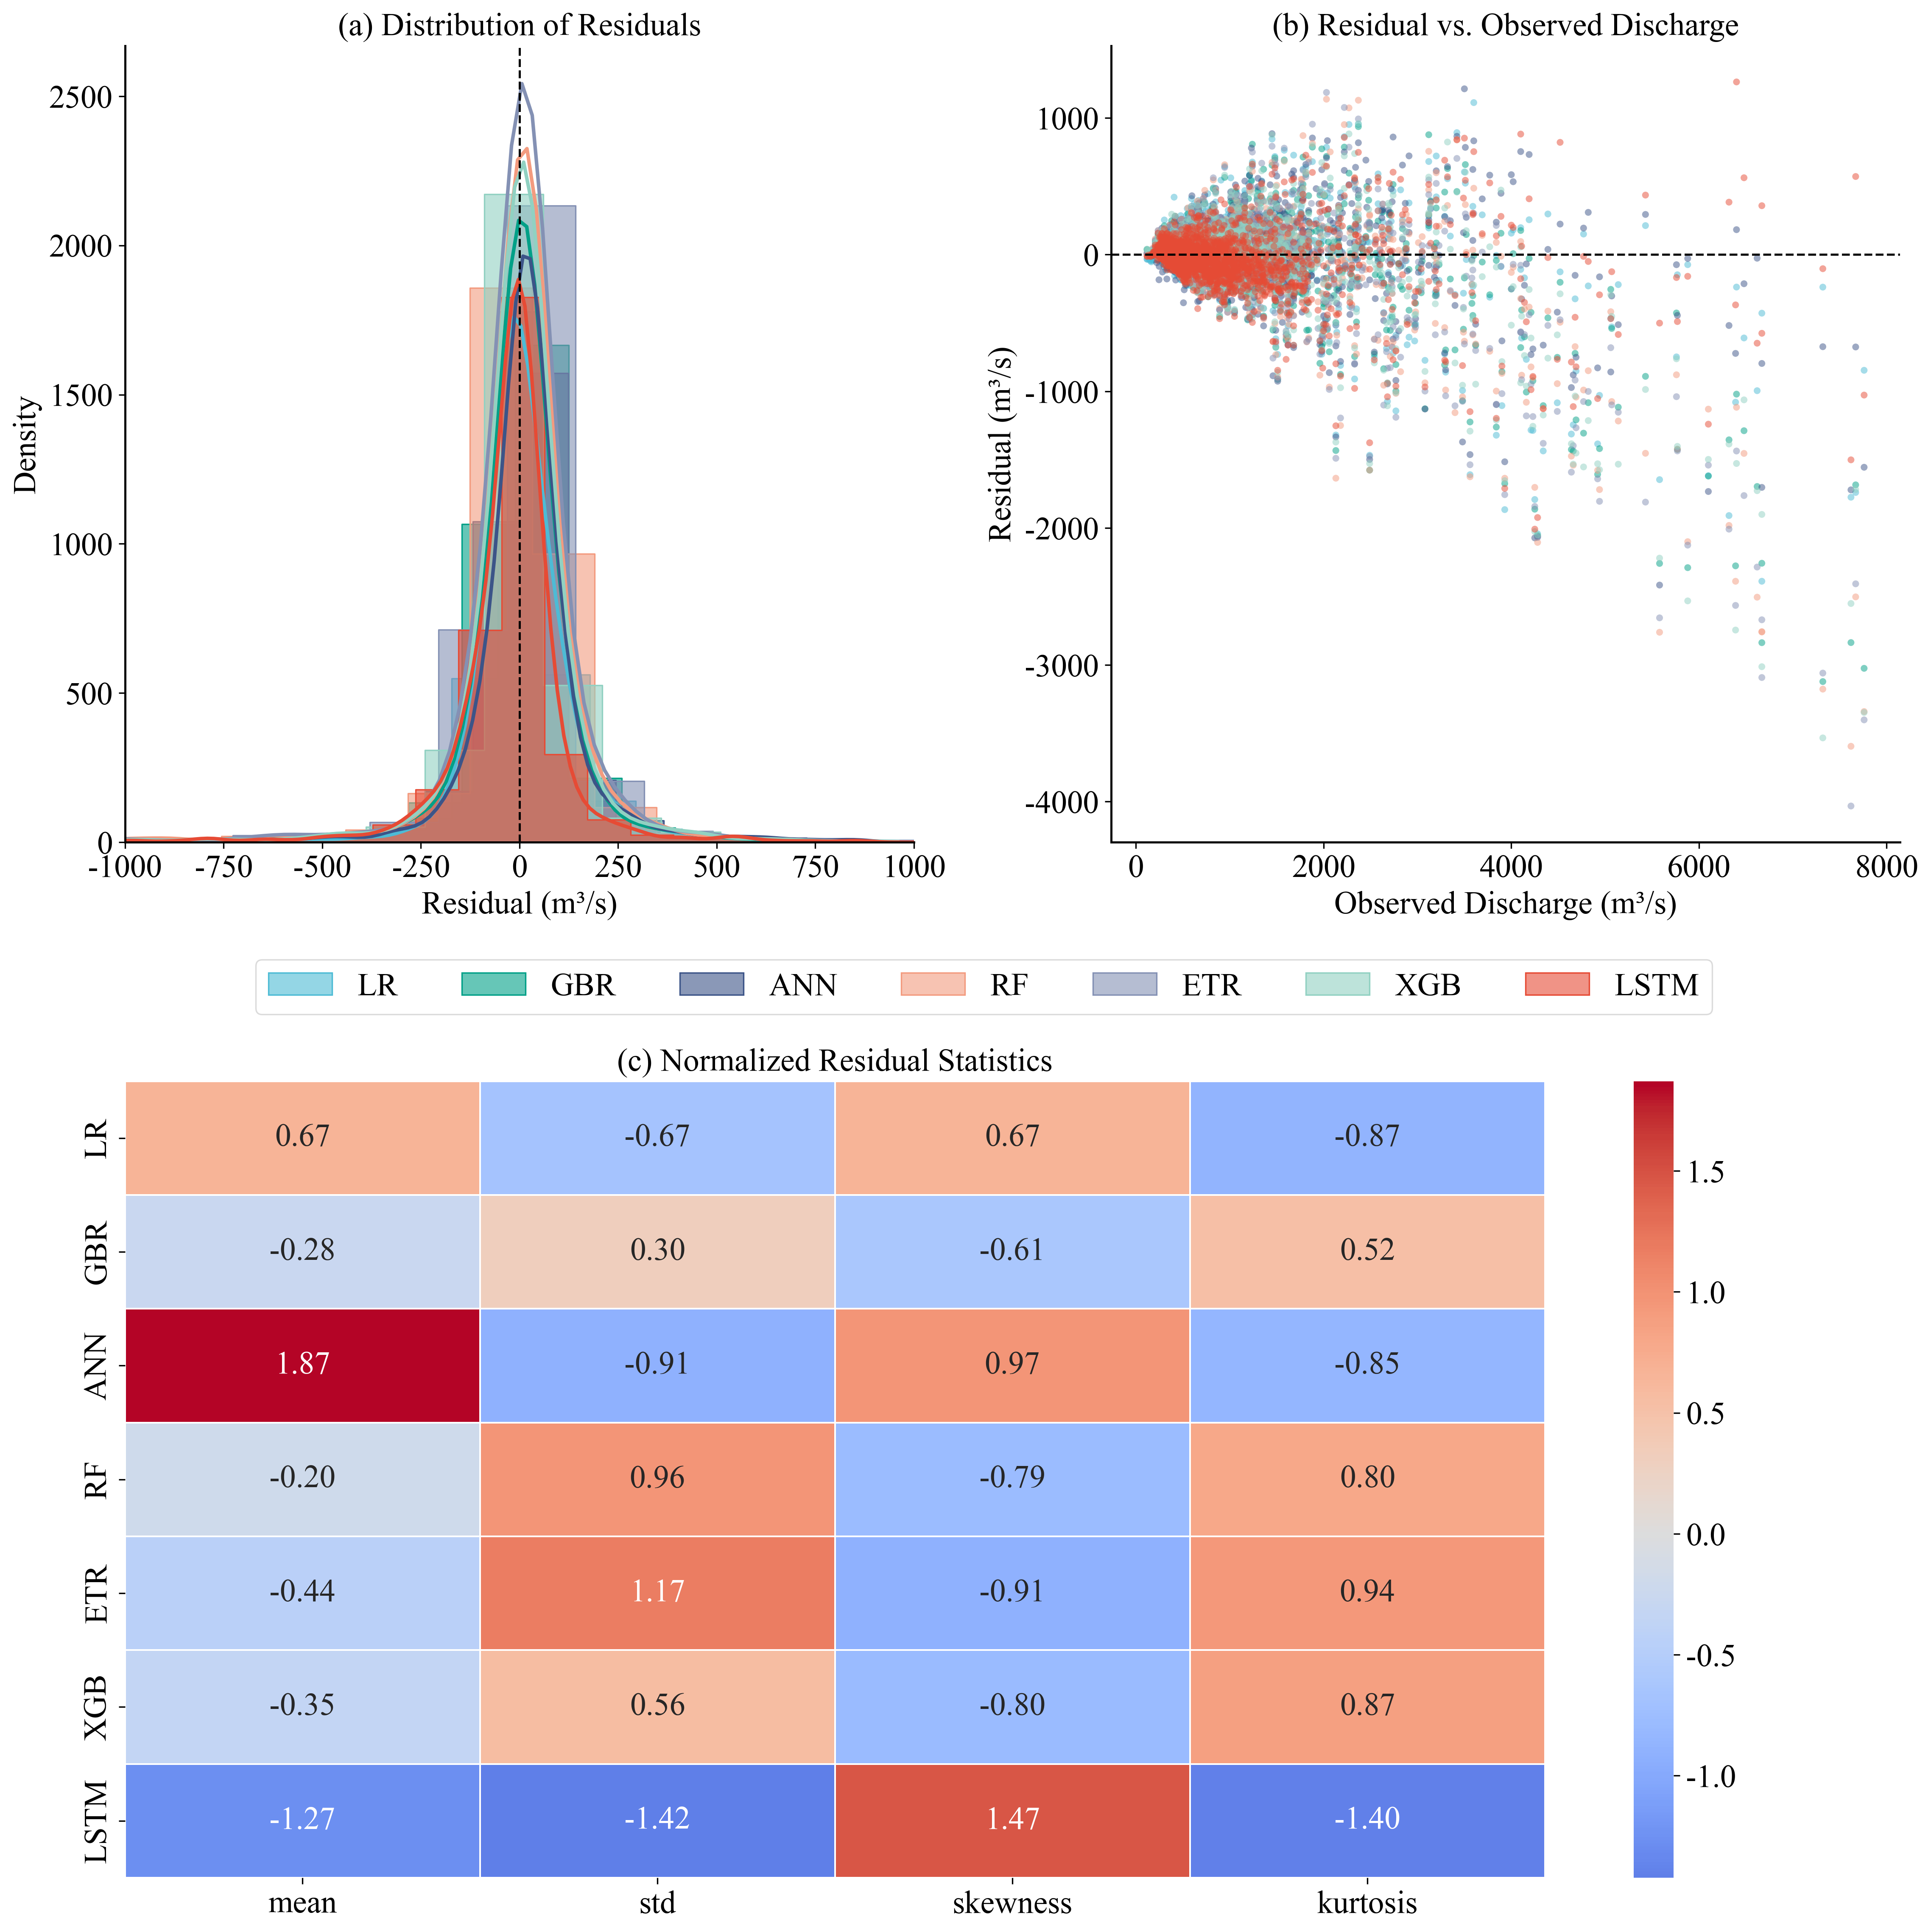

残差分析完成，结果保存于: results/Figure4_residual_analysis_simplified.png


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import seaborn as sns
from scipy import stats
from matplotlib.gridspec import GridSpec

# -------------------------- 基础配置 --------------------------
plt.rcParams["font.family"] = ["Times New Roman"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 16
plt.rcParams["axes.labelsize"] = 18
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["legend.fontsize"] = 18
plt.rcParams["xtick.labelsize"] = 18
plt.rcParams["ytick.labelsize"] = 18
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["lines.linewidth"] = 2.0
plt.rcParams["lines.markersize"] = 4
plt.rcParams["patch.edgecolor"] = "white"
plt.rcParams["patch.linewidth"] = 0.8

# 模型样式配置
MODEL_STYLE = {
    "order": ["LR", "GBR", "ANN", "RF", "ETR", "XGB", "LSTM"],  # 添加LSTM
    "color": {
        "LR": "#4DBBD5",
        "GBR": "#00A087",
        "ANN": "#3C5488",
        "RF": "#F39B7F",
        "ETR": "#8491B4",
        "XGB": "#91D1C2",
        "LSTM": "#E64B35"  # LSTM使用砖红色
    },
    "marker": {
        "LR": "o",
        "GBR": "s",
        "ANN": "^",
        "RF": "D",
        "ETR": "v",
        "XGB": "<",
        "LSTM": ">"  # LSTM使用右三角
    }
}

# -------------------------- 数据处理函数 --------------------------
def load_model_predictions(pred_dir='predictions'):
    """加载所有模型的预测数据并计算残差"""
    predictions = {}
    
    if not os.path.exists(pred_dir):
        raise FileNotFoundError(f"预测数据目录不存在: {pred_dir}")
    
    for filename in os.listdir(pred_dir):
        if filename.endswith('_predictions.csv'):
            model_name = filename.replace('_predictions.csv', '')
            file_path = os.path.join(pred_dir, filename)
            
            pred_df = pd.read_csv(file_path)
            required_cols = ['date', 'observed', 'predicted']
            if not all(col in pred_df.columns for col in required_cols):
                missing = [col for col in required_cols if col not in pred_df.columns]
                print(f"警告: {filename} 缺少必要列 {missing}，已跳过")
                continue
            
            # 计算残差
            pred_df['date'] = pd.to_datetime(pred_df['date'])
            pred_df['residual'] = pred_df['predicted'] - pred_df['observed']
            pred_df['abs_residual'] = np.abs(pred_df['residual'])
            pred_df['observed_norm'] = pred_df['observed'] / pred_df['observed'].max()
            
            # 移除可能的NaN值
            pred_df = pred_df.dropna(subset=['abs_residual', 'residual', 'observed'])
            
            # 确保数据量充足
            if len(pred_df) < 10:
                print(f"警告: 模型 {model_name} 数据点太少 ({len(pred_df)}个)，已跳过")
                continue
            
            predictions[model_name] = pred_df
    
    # ========== 新增：单独读取LSTM预测文件 ==========
    lstm_path = 'models/lstm/lstm_test_predictions.csv'
    if os.path.exists(lstm_path):
        try:
            lstm_df = pd.read_csv(lstm_path)
            # LSTM文件列名为大写开头，需要转换
            lstm_df.columns = lstm_df.columns.str.lower()
            lstm_df['date'] = pd.to_datetime(lstm_df['date'])
            lstm_df['residual'] = lstm_df['predicted'] - lstm_df['observed']
            lstm_df['abs_residual'] = np.abs(lstm_df['residual'])
            lstm_df['observed_norm'] = lstm_df['observed'] / lstm_df['observed'].max()
            lstm_df = lstm_df.dropna(subset=['abs_residual', 'residual', 'observed'])
            predictions['LSTM'] = lstm_df
            print(f"成功加载LSTM预测数据: {lstm_path}")
        except Exception as e:
            print(f"读取LSTM预测文件失败: {str(e)}")
    else:
        print(f"警告: LSTM预测文件不存在: {lstm_path}")
    # ========== 新增结束 ==========
    
    if not predictions:
        raise ValueError(f"未在 {pred_dir} 找到有效预测文件")
    
    # 按指定顺序筛选模型
    valid_models = [model for model in MODEL_STYLE["order"] if model in predictions]
    return {model: predictions[model] for model in valid_models}

def calculate_residual_stats(residuals):
    """计算残差的统计指标"""
    stats_dict = {
        'mean': np.mean(residuals),
        'median': np.median(residuals),
        'std': np.std(residuals),
        'rmse': np.sqrt(np.mean(residuals**2)),
        'mae': np.mean(np.abs(residuals)),
        'skewness': stats.skew(residuals),
        'kurtosis': stats.kurtosis(residuals),
        'jarque_bera': stats.jarque_bera(residuals)[0],
        'count': len(residuals)
    }
    return stats_dict

# -------------------------- 绘图函数 --------------------------
def plot_residual_analysis(predictions, output_file='results/Figure4_residual_analysis_simplified.png',
                          figsize=(18, 18), dpi=300):
    """绘制包含a、d、e三幅子图的残差分析图"""
    models = list(predictions.keys())
    if not models:
        raise ValueError("没有可分析的模型数据")
    
    # 创建网格布局 - 2行2列，只使用其中3个位置
    fig = plt.figure(figsize=figsize, dpi=dpi)
    gs = GridSpec(2, 2, figure=fig, 
                 hspace=0.3, wspace=0.25,
                 height_ratios=[1, 1],
                 width_ratios=[1, 1])
    
    # a. 残差分布直方图 (左上)
    ax_a = fig.add_subplot(gs[0, 0])
    # d. 残差与观测值关系 (右上)
    ax_d = fig.add_subplot(gs[0, 1])
    # e. 残差统计指标 (下方横跨两列)
    ax_e = fig.add_subplot(gs[1, :])
    
    # 存储所有模型的残差统计量
    residual_stats = {}
    
    # 处理每个模型的数据
    for model in models:
        df = predictions[model].copy()
        residuals = df['residual'].values
        residual_stats[model] = calculate_residual_stats(residuals)
        
        color = MODEL_STYLE["color"][model]
        marker = MODEL_STYLE["marker"][model]
        
        # ---------------------- a. 残差分布直方图 ----------------------
        sns.histplot(ax=ax_a, data=residuals, color=color, label=model,
                    alpha=0.6, bins=30, kde=True, element='step')
        
        # ---------------------- d. 残差与观测值关系 ----------------------
        ax_d.scatter(df['observed'], df['residual'], color=color, label=model,
                   alpha=0.5, s=15, edgecolor='none')
    
    # ---------------------- 美化各个子图 ----------------------
    
    # a. 残差分布直方图
    ax_a.axvline(x=0, color='black', linestyle='--', linewidth=1.2)
    ax_a.set_xlabel('Residual (m³/s)')
    ax_a.set_ylabel('Density')
    ax_a.set_title('(a) Distribution of Residuals')
    ax_a.set_xlim(-1000, 1000)  # 固定横坐标范围
    ax_a.spines['top'].set_visible(False)
    ax_a.spines['right'].set_visible(False)
    
    # d. 残差与观测值关系
    ax_d.axhline(y=0, color='black', linestyle='--', linewidth=1.2)
    ax_d.set_xlabel('Observed Discharge (m³/s)')
    ax_d.set_ylabel('Residual (m³/s)')
    ax_d.set_title('(b) Residual vs. Observed Discharge')
    ax_d.spines['top'].set_visible(False)
    ax_d.spines['right'].set_visible(False)
    
    # e. 残差统计指标热图
    stats_df = pd.DataFrame(residual_stats).T[['mean', 'std', 'skewness', 'kurtosis']]
    norm_stats_df = (stats_df - stats_df.mean()) / stats_df.std()
    sns.heatmap(ax=ax_e, data=norm_stats_df, annot=True, fmt='.2f',
               cmap='coolwarm', center=0, cbar=True,
               annot_kws={"size": 18}, linewidths=0.5)
    ax_e.set_title('(c) Normalized Residual Statistics')
    
    # ========== 新增：打印残差统计信息 ==========
    print("\n" + "="*100)
    print("残差分析统计结果")
    print("="*100)
    
    # 打印详细统计表
    print(f"\n{'模型':<8} {'均值(m³/s)':<14} {'标准差(m³/s)':<14} {'RMSE(m³/s)':<14} {'MAE(m³/s)':<14} {'偏度':<10} {'峰度':<10}")
    print("-"*100)
    
    for model in models:
        s = residual_stats[model]
        print(f"{model:<8} {s['mean']:<14.2f} {s['std']:<14.2f} {s['rmse']:<14.2f} {s['mae']:<14.2f} {s['skewness']:<10.3f} {s['kurtosis']:<10.3f}")
    
    print("-"*100)
    
    # 找出最佳模型（基于不同指标）
    best_rmse = min(models, key=lambda m: residual_stats[m]['rmse'])
    best_mae = min(models, key=lambda m: residual_stats[m]['mae'])
    best_std = min(models, key=lambda m: residual_stats[m]['std'])
    best_mean = min(models, key=lambda m: abs(residual_stats[m]['mean']))  # 均值最接近0
    
    print(f"\n最佳模型汇总:")
    print(f"  RMSE最低:     {best_rmse:<8} ({residual_stats[best_rmse]['rmse']:.2f} m³/s)")
    print(f"  MAE最低:      {best_mae:<8} ({residual_stats[best_mae]['mae']:.2f} m³/s)")
    print(f"  标准差最低:   {best_std:<8} ({residual_stats[best_std]['std']:.2f} m³/s)")
    print(f"  均值最接近0:  {best_mean:<8} ({residual_stats[best_mean]['mean']:.2f} m³/s)")
    
    # 打印偏度和峰度分析
    print(f"\n残差分布特征分析:")
    print("-"*100)
    for model in models:
        s = residual_stats[model]
        # 偏度分析
        if s['skewness'] > 0.5:
            skew_desc = "正偏(右偏，倾向低估)"
        elif s['skewness'] < -0.5:
            skew_desc = "负偏(左偏，倾向高估)"
        else:
            skew_desc = "近似对称"
        
        # 峰度分析
        if s['kurtosis'] > 1:
            kurt_desc = "尖峰(重尾，存在极端误差)"
        elif s['kurtosis'] < -1:
            kurt_desc = "平峰(轻尾)"
        else:
            kurt_desc = "近似正态"
        
        print(f"  {model:<8}: {skew_desc:<20} | {kurt_desc}")
    
    # 打印归一化统计表（用于热图）
    print(f"\n归一化残差统计 (用于热图):")
    print("-"*100)
    print(norm_stats_df.round(2).to_string())
    
    print("\n" + "="*100)
    # ========== 新增结束 ==========
    
    # 添加统一图例
    handles, labels = ax_a.get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=7,
              frameon=True, edgecolor='lightgray',
              bbox_to_anchor=(0.5, 0.45), bbox_transform=plt.gcf().transFigure)
    
    # 调整布局
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)
    
    # 保存图像
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    plt.savefig(output_file, dpi=dpi, bbox_inches='tight', pad_inches=0.5)
    print(f"\n简化版残差分析图已保存至: {output_file}")
    
    # 显示图形
    plt.show()
    return output_file

# -------------------------- 主函数 --------------------------
def main():
    print("正在加载模型预测数据并计算残差...")
    model_data = load_model_predictions(pred_dir='predictions')
    print(f"成功加载 {len(model_data)} 个模型的数据")
    
    print("正在绘制简化版残差分析图...")
    save_path = plot_residual_analysis(model_data)
    print(f"残差分析完成，结果保存于: {save_path}")

if __name__ == "__main__":
    main()
